# Identificação de inovações do agronegócio no dataset completo DL-2024

## NER, BERTimbau e clusterização — versão com todo o corpus

Este notebook utiliza **todas as descrições válidas do dataset DL-2024**, sem aplicar filtro temático e sem limitar a quantidade de textos nos embeddings. O dicionário especializado do agronegócio é aplicado sobre o corpus completo para identificar onde aparecem tecnologias, equipamentos, práticas, insumos, cadeias produtivas, aplicações, benefícios, desafios e indicadores agrícolas.

A clusterização também é realizada sobre o dataset completo. Por isso, os grupos podem representar assuntos não agrícolas. A presença de conteúdo do agro é medida dentro de cada cluster por indicadores específicos.

## 1. Instalação das dependências

In [1]:
# Execute em um ambiente novo, como o Google Colab.
!pip -q install kagglehub pandas numpy scikit-learn transformers accelerate spacy matplotlib unidecode openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.4 MB/s eta 0:00:00


## 2. Importações e configurações

In [2]:
import os
import re
import glob
import json
import math
import random
import shutil
import warnings
import unicodedata
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
import torch

from IPython.display import display
from spacy.matcher import PhraseMatcher
from spacy.tokens import Span
from spacy.training import Example
from spacy.util import filter_spans, minibatch, compounding

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
DATASET_SLUG = 'georgekurokijr/dl-2024'
MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'

# Informe um arquivo local para priorizá-lo. Deixe None para baixar o DL-2024.
CAMINHO_ARQUIVO = None
USAR_KAGGLE_DL2024 = True

MAX_SENTENCAS_NER = None  # None = usar todas as sentenças positivas encontradas
PROPORCAO_NEGATIVOS = 0.25
NER_EPOCHS = 30
NER_PATIENCE = 6

MAX_TEXTOS_EMBEDDINGS = None  # None = usar todas as descrições válidas
MAX_LEN = 256
BATCH_SIZE = 16
MIN_K = 2
MAX_K = 15
SEMENTES_CLUSTER = [13, 42, 77, 101, 123]

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

Dispositivo: cuda


## 3. Dicionário especializado do agronegócio

As categorias representam tecnologias, equipamentos, práticas, insumos, cadeias produtivas, aplicações, benefícios, desafios e indicadores.

In [3]:
DICIONARIO_AGRO = {
    "TECNOLOGIA": [
        "inteligência artificial", "IA", "aprendizado de máquina", "machine learning",
        "aprendizado profundo", "deep learning", "visão computacional",
        "internet das coisas", "IoT", "big data", "computação em nuvem",
        "computação de borda", "edge computing", "blockchain",
        "contrato inteligente", "smart contract", "gêmeo digital", "digital twin",
        "sensoriamento remoto", "geoprocessamento", "sistema de informação geográfica",
        "SIG", "GNSS", "GPS", "telemetria", "conectividade 5G", "5G",
        "LoRa", "LoRaWAN", "RFID", "NFC", "automação agrícola",
        "robótica agrícola", "modelagem preditiva", "análise preditiva",
        "modelos generativos", "imagens multiespectrais", "imagens hiperespectrais",
        "LiDAR", "fusão de sensores", "plataforma digital", "aplicativo móvel",
        "sistema de apoio à decisão", "software de gestão rural"
    ],

    "EQUIPAMENTO": [
        "drone", "drones", "VANT", "veículo aéreo não tripulado", "satélite",
        "sensor de umidade", "sensor de solo", "sensor óptico", "sensor multiespectral",
        "sensor hiperespectral", "sensor térmico", "sensor climático",
        "sensor de temperatura", "sensor de pH", "estação meteorológica",
        "armadilha inteligente", "câmera multiespectral", "câmera hiperespectral",
        "câmera térmica", "robô agrícola", "trator autônomo",
        "pulverizador autônomo", "pulverizador seletivo", "colheitadeira",
        "semeadora", "plantadeira", "ordenhadeira robotizada", "brinco eletrônico",
        "coleira inteligente", "balança automática", "silo inteligente",
        "clorofilômetro", "penetrômetro", "controlador de irrigação",
        "pivô central inteligente", "medidor de vazão", "monitor de produtividade",
        "estação agrometeorológica", "veículo terrestre não tripulado",
        "distribuidor de fertilizantes", "máquina de visão"
    ],

    "PRATICA_PROCESSO": [
        "agricultura de precisão", "agricultura digital", "agricultura 4.0",
        "agricultura inteligente", "agricultura regenerativa", "plantio direto",
        "integração lavoura-pecuária-floresta", "ILPF", "manejo integrado de pragas",
        "MIP", "controle biológico", "manejo em taxa variável",
        "aplicação em taxa variável", "pulverização de precisão",
        "pulverização seletiva", "irrigação de precisão", "irrigação inteligente",
        "fertirrigação", "semeadura de precisão", "monitoramento em tempo real",
        "rastreabilidade", "manejo conservacionista", "rotação de culturas",
        "fixação biológica de nitrogênio", "FBN", "cultivo protegido", "hidroponia",
        "agrofloresta", "manejo de pastagem", "confinamento de precisão",
        "pecuária de precisão", "manejo voltado ao bem-estar animal",
        "processamento mínimo", "secagem de grãos", "armazenagem inteligente",
        "logística inteligente", "economia circular", "produção de baixo carbono",
        "agricultura vertical", "bioeconomia", "manejo localizado",
        "aplicação localizada", "colheita mecanizada", "plantio mecanizado"
    ],

    "INSUMO": [
        "bioinsumo", "bioinsumos", "biofertilizante", "inoculante", "biopesticida",
        "biofungicida", "bioinseticida", "bionematicida",
        "agente de controle biológico", "microrganismo promotor de crescimento",
        "fertilizante organomineral", "fertilizante de liberação controlada",
        "nanofertilizante", "condicionador de solo", "corretivo de solo",
        "semente melhorada", "semente certificada", "cultivar transgênica",
        "cultivar editada", "defensivo agrícola", "herbicida", "fungicida",
        "inseticida", "adjuvante", "feromônio", "inibidor de nitrificação",
        "ração de precisão", "aditivo alimentar", "vacina veterinária",
        "biocarvão", "biochar", "composto orgânico", "fertilizante biológico",
        "nanopartícula", "semente tratada", "probiótico animal", "biomassa residual"
    ],

    "CADEIA_PRODUTIVA": [
        "soja", "milho", "cana-de-açúcar", "cana de açúcar", "café", "algodão",
        "arroz", "feijão", "trigo", "sorgo", "cevada", "aveia", "girassol",
        "amendoim", "mandioca", "batata", "tomate", "laranja", "uva", "maçã",
        "cacau", "açaí", "banana", "manga", "eucalipto", "pinus", "pastagem",
        "bovinocultura", "gado de corte", "gado leiteiro", "leite", "avicultura",
        "frango de corte", "suinocultura", "aquicultura", "piscicultura",
        "apicultura", "horticultura", "fruticultura", "silvicultura",
        "olericultura", "floricultura", "produção de grãos", "cadeia de carnes"
    ],

    "APLICACAO": [
        "monitoramento de lavouras", "monitoramento do solo", "mapeamento de produtividade",
        "detecção de pragas", "detecção de doenças", "diagnóstico de doenças",
        "identificação de plantas daninhas", "previsão de safra",
        "previsão de produtividade", "estimativa de produtividade",
        "classificação de grãos", "controle de irrigação", "otimização da irrigação",
        "aplicação localizada de insumos", "controle de pulverização",
        "rastreabilidade de alimentos", "rastreabilidade da produção",
        "monitoramento climático", "previsão meteorológica", "zoneamento agrícola",
        "detecção de estresse hídrico", "detecção de deficiência nutricional",
        "análise de solo", "recomendação de adubação", "seleção de sementes",
        "melhoramento genético", "monitoramento animal", "detecção de cio",
        "detecção de mastite", "controle de qualidade", "gestão de estoque",
        "monitoramento de silos", "previsão de preços", "otimização logística",
        "planejamento de rotas", "gestão de máquinas", "manutenção preditiva",
        "contagem de plantas", "contagem de frutos", "estimativa de biomassa",
        "monitoramento de desmatamento", "medição de emissões",
        "contabilidade de carbono", "previsão de demanda", "detecção de fraude",
        "certificação de origem", "identificação de falhas de plantio",
        "monitoramento de pastagens", "seleção de cultivares", "classificação de frutas",
        "predição de doenças", "controle de ambiência", "gestão da propriedade rural"
    ],

    "BENEFICIO": [
        "aumento de produtividade", "ganho de produtividade", "redução de custos",
        "redução de perdas", "economia de água", "economia de energia",
        "redução do uso de defensivos", "redução de agrotóxicos",
        "redução do uso de fertilizantes", "uso eficiente de insumos",
        "maior eficiência operacional", "melhoria da qualidade",
        "aumento da rentabilidade", "redução de emissões", "sequestro de carbono",
        "conservação do solo", "conservação da água", "bem-estar animal",
        "segurança alimentar", "resiliência climática",
        "melhoria da tomada de decisão", "redução de mão de obra",
        "otimização de recursos", "sustentabilidade", "maior precisão",
        "redução de desperdício", "aumento da rastreabilidade",
        "maior previsibilidade", "redução de riscos", "valorização do produto",
        "aumento da eficiência", "redução do consumo de combustível",
        "melhoria da sanidade", "redução do impacto ambiental",
        "aumento da vida útil", "qualidade pós-colheita"
    ],

    "DESAFIO": [
        "mudança climática", "mudanças climáticas", "variabilidade climática",
        "seca", "estiagem", "geada", "enchente", "inundação", "erosão do solo",
        "compactação do solo", "degradação do solo", "estresse hídrico", "praga",
        "pragas", "doença", "doenças", "planta daninha", "plantas daninhas",
        "resistência a defensivos", "perda pós-colheita", "desperdício de alimentos",
        "alto custo de produção", "falta de conectividade", "baixa conectividade",
        "interoperabilidade", "segurança de dados", "privacidade de dados",
        "escassez de mão de obra", "falta de assistência técnica",
        "barreira de adoção", "custo de implementação", "dependência tecnológica",
        "volatilidade de preços", "risco climático", "desmatamento",
        "emissão de gases de efeito estufa", "contaminação do solo",
        "contaminação da água", "degradação de pastagens", "perda de biodiversidade",
        "salinização do solo", "deficiência nutricional", "falha de plantio",
        "baixa produtividade", "perda de qualidade", "doença animal"
    ],

    "INDICADOR": [
        "NDVI", "NDRE", "EVI", "índice de vegetação", "índice de área foliar",
        "LAI", "umidade do solo", "temperatura do solo", "temperatura do ar",
        "precipitação", "evapotranspiração", "condutividade elétrica", "pH do solo",
        "matéria orgânica", "teor de nitrogênio", "biomassa", "produtividade",
        "taxa de aplicação", "velocidade de operação", "consumo de combustível",
        "emissão de metano", "pegada de carbono", "teor de clorofila",
        "índice pluviométrico", "déficit hídrico", "umidade relativa",
        "pressão atmosférica", "radiação solar", "vigor vegetativo",
        "temperatura foliar", "taxa de lotação", "conversão alimentar",
        "peso vivo", "qualidade do grão", "teor de proteína", "nível de infestação"
    ]
}

### 3.1 Validação do dicionário

In [4]:
def normalizar_texto(texto):
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r'\s+', ' ', texto)
    return texto


def analisar_dicionario(dicionario):
    indice = defaultdict(list)
    linhas = []

    for categoria, termos in dicionario.items():
        termos_limpos = sorted({str(t).strip() for t in termos if str(t).strip()})
        for termo in termos_limpos:
            indice[normalizar_texto(termo)].append(categoria)
            linhas.append({'categoria': categoria, 'termo': termo})

    duplicados = {t: cats for t, cats in indice.items() if len(set(cats)) > 1}
    resumo = pd.DataFrame(linhas).groupby('categoria').size().reset_index(name='quantidade')

    print('Total de termos:', len(linhas))
    print('Categorias:', len(dicionario))
    print('Termos presentes em mais de uma categoria:', len(duplicados))
    display(resumo.sort_values('quantidade', ascending=False))

    if duplicados:
        print('Revise as ambiguidades abaixo:')
        display(pd.DataFrame([
            {'termo_normalizado': termo, 'categorias': ', '.join(sorted(set(cats)))}
            for termo, cats in duplicados.items()
        ]))

    return pd.DataFrame(linhas), duplicados


df_dicionario, duplicados_dicionario = analisar_dicionario(DICIONARIO_AGRO)

Total de termos: 381
Categorias: 9
Termos presentes em mais de uma categoria: 0


,categoria,quantidade
0,APLICACAO,53
3,DESAFIO,46
2,CADEIA_PRODUTIVA,44
7,PRATICA_PROCESSO,44
8,TECNOLOGIA,44
4,EQUIPAMENTO,41
6,INSUMO,37
1,BENEFICIO,36
5,INDICADOR,36


## 4. Carregamento robusto do corpus

A função abaixo tenta diferentes codificações. Para arquivos TSV, o separador é definido como tabulação. O DL-2024 possui as colunas `Título_Público` e `Descricao_pública` e normalmente utiliza `latin-1`.

In [5]:
def read_table_robusto(file_path):
    file_path = str(file_path)
    lower = file_path.lower()

    if lower.endswith('.xlsx'):
        return pd.read_excel(file_path)
    if lower.endswith('.parquet'):
        return pd.read_parquet(file_path)
    if lower.endswith('.jsonl'):
        return pd.read_json(file_path, lines=True)
    if lower.endswith('.json'):
        return pd.read_json(file_path)

    if lower.endswith('.tsv'):
        separadores = ['\t']
    elif lower.endswith('.csv'):
        separadores = [None, ';', ',', '\t']
    else:
        raise ValueError(f'Formato não suportado: {file_path}')

    erros = []
    for encoding in ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']:
        for sep in separadores:
            try:
                df_lido = pd.read_csv(
                    file_path,
                    encoding=encoding,
                    sep=sep,
                    engine='python'
                )
                if df_lido.shape[1] >= 2:
                    print(f'Leitura concluída: encoding={encoding!r}, sep={sep!r}')
                    return df_lido
            except Exception as exc:
                erros.append(f'{encoding}/{sep}: {type(exc).__name__}')

    raise RuntimeError('Não foi possível ler o arquivo. Tentativas: ' + ' | '.join(erros[-8:]))


def localizar_primeiro_tabular(base_path):
    extensoes = ('.csv', '.tsv', '.xlsx', '.json', '.jsonl', '.parquet')
    arquivos = [
        p for p in glob.glob(os.path.join(str(base_path), '**', '*'), recursive=True)
        if os.path.isfile(p) and p.lower().endswith(extensoes)
    ]
    if not arquivos:
        raise FileNotFoundError('Nenhum arquivo tabular foi encontrado.')
    return sorted(arquivos)[0]


def carregar_corpus_bruto():
    if CAMINHO_ARQUIVO:
        caminho = Path(CAMINHO_ARQUIVO)
        if not caminho.exists():
            raise FileNotFoundError(f'Arquivo não encontrado: {caminho}')
        return read_table_robusto(caminho), str(caminho), 'arquivo informado pelo usuário'

    if USAR_KAGGLE_DL2024:
        dataset_path = kagglehub.dataset_download(DATASET_SLUG)
        arquivo = localizar_primeiro_tabular(dataset_path)
        return read_table_robusto(arquivo), arquivo, 'DL-2024'

    raise ValueError('Defina CAMINHO_ARQUIVO ou habilite USAR_KAGGLE_DL2024.')

### 4.1 Identificação das colunas e preparação do dataset completo

Somente registros sem descrição são removidos. Duplicatas são **mantidas**, para que o notebook represente o dataset completo, mas recebem uma marcação específica. A divisão do NER usa um identificador de texto normalizado para impedir que descrições iguais apareçam simultaneamente no treino e na validação.

In [6]:
def normalizar_nome_coluna(nome):
    nome = normalizar_texto(nome)
    nome = re.sub(r'[^a-z0-9]+', '_', nome).strip('_')
    return nome


def encontrar_coluna(df, candidatos):
    mapa = {normalizar_nome_coluna(c): c for c in df.columns}
    for candidato in candidatos:
        if candidato in mapa:
            return mapa[candidato]
    return None


def limpar_descricao(texto):
    if pd.isna(texto):
        return ''
    texto = str(texto)
    texto = re.sub(r'https?://\S+|www\.\S+', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


def remover_abertura_generica(texto):
    # Remove apenas expressões introdutórias no começo. O conteúdo semântico é preservado.
    padroes = [
        r'^o presente (projeto|trabalho|estudo) (tem como objetivo|objetiva|visa)\s*',
        r'^este (projeto|trabalho|estudo) (tem como objetivo|objetiva|visa)\s*',
        r'^o objetivo (geral )?(deste|desse|do presente) (projeto|trabalho|estudo) (é|consiste em)\s*',
        r'^a presente proposta (tem como objetivo|objetiva|visa)\s*',
    ]
    resultado = str(texto).strip()
    for padrao in padroes:
        resultado = re.sub(padrao, '', resultado, flags=re.IGNORECASE)
    return resultado.strip(' .;:-')


df_bruto, caminho_fonte, nome_fonte = carregar_corpus_bruto()
print('Fonte:', nome_fonte)
print('Arquivo:', caminho_fonte)
print('Dimensões brutas:', df_bruto.shape)
print('Colunas:', list(df_bruto.columns))

TITLE_CANDIDATES = ['titulo_publico', 'titulo', 'title', 'nome_publico', 'projeto', 'nome_projeto']
DESCRIPTION_CANDIDATES = ['descricao_publica', 'descricao', 'description', 'resumo', 'abstract']

col_titulo = encontrar_coluna(df_bruto, TITLE_CANDIDATES)
col_descricao = encontrar_coluna(df_bruto, DESCRIPTION_CANDIDATES)

colunas_textuais = [c for c in df_bruto.columns if df_bruto[c].dtype == 'object']
if col_descricao is None:
    if not colunas_textuais:
        raise ValueError('Nenhuma coluna textual foi encontrada.')
    col_descricao = colunas_textuais[-1]
if col_titulo is None:
    col_titulo = colunas_textuais[0] if len(colunas_textuais) > 1 else col_descricao

print('Coluna de título:', col_titulo)
print('Coluna de descrição:', col_descricao)

df_base = pd.DataFrame({
    'linha_original': np.arange(len(df_bruto)),
    'titulo': df_bruto[col_titulo].fillna('').astype(str).str.strip(),
    'descricao': df_bruto[col_descricao].map(limpar_descricao),
})

quantidade_sem_descricao = int((df_base['descricao'].str.len() == 0).sum())
df_base = df_base[df_base['descricao'].str.len() > 0].copy().reset_index(drop=True)
df_base['descricao_normalizada'] = df_base['descricao'].map(normalizar_texto)
df_base['duplicado_descricao'] = df_base.duplicated('descricao_normalizada', keep=False)
df_base['grupo_texto'] = pd.factorize(df_base['descricao_normalizada'])[0]
df_base['documento_id'] = np.arange(len(df_base))
df_base['texto_cluster'] = df_base['descricao'].map(remover_abertura_generica)

print('Registros brutos:', len(df_bruto))
print('Registros removidos por descrição vazia:', quantidade_sem_descricao)
print('Registros válidos utilizados:', len(df_base))
print('Registros pertencentes a grupos duplicados:', int(df_base['duplicado_descricao'].sum()))
print('Descrições únicas:', df_base['grupo_texto'].nunique())

display(df_base[['linha_original', 'titulo', 'duplicado_descricao', 'descricao']].head())

Using Colab cache for faster access to the 'dl-2024' dataset.
Leitura concluída: encoding='latin-1', sep='\t'
Fonte: DL-2024
Arquivo: /kaggle/input/dl-2024/dadosTextosCientificos.tsv
Dimensões brutas: (2725, 2)
Colunas: ['Título_Público', 'Descricao_pública']
Coluna de título: Título_Público
Coluna de descrição: Descricao_pública
Registros brutos: 2725
Registros removidos por descrição vazia: 4
Registros válidos utilizados: 2721
Registros pertencentes a grupos duplicados: 43
Descrições únicas: 2697


,linha_original,titulo,duplicado_descricao,descricao
0,0,Açúcar de frutas e aplicação em bolos como sub...,False,O uso de inovações tecnológicas auxilia as ind...
1,1,Desenvolver uma linha de farofas com castanhas...,False,O uso de inovações tecnológicas auxilia as ind...
2,2,Desenvolvimento de cobertura líquida para sorvete,False,O Brasil é considerado um país com a maior bio...
3,3,Desenvolvimento de conserva de tomate cereja,False,O Brasil é considerado o país com maior biodiv...
4,4,Desenvolvimento de massa alimentícia enriqueci...,False,Nos últimos anos a comunidade científica tem d...


## 5. Uso do dataset completo e marcação da presença de agro

Nenhum texto é excluído por assunto. Os termos de alta precisão são utilizados apenas para criar indicadores de presença de conteúdo agrícola. Assim, o corpus completo entra no NER, nos embeddings e na clusterização.

In [7]:
TERMOS_AGRO_ADICIONAIS = [
    'agronegócio', 'agropecuária', 'agroindustrial', 'agrícola', 'agricultura',
    'lavoura', 'cultivo', 'plantio', 'colheita', 'safra', 'solo', 'sementes',
    'alimento', 'alimentos', 'indústria de alimentos', 'produção rural',
    'pecuária', 'rebanho', 'pastagem', 'irrigação', 'fertilizante',
    'bioinsumo', 'agtech', 'fazenda', 'produtor rural', 'pós-colheita'
]

CATEGORIAS_INDICIO_AGRO = [
    'CADEIA_PRODUTIVA', 'PRATICA_PROCESSO', 'INSUMO',
    'EQUIPAMENTO', 'APLICACAO', 'DESAFIO'
]

termos_indicio_agro = set(TERMOS_AGRO_ADICIONAIS)
for categoria in CATEGORIAS_INDICIO_AGRO:
    termos_indicio_agro.update(DICIONARIO_AGRO[categoria])

# Termos curtos e excessivamente genéricos são retirados apenas do indicador inicial.
EXCLUIR_INDICIO = {
    normalizar_texto(t) for t in {
        'praga', 'doença', 'seca', 'leite', 'arroz', 'café', 'milho', 'soja',
        'sensor', 'satélite', 'produto', 'processo', 'sistema'
    }
}

termos_indicio_agro = sorted({
    normalizar_texto(t) for t in termos_indicio_agro
    if len(normalizar_texto(t)) >= 4 and normalizar_texto(t) not in EXCLUIR_INDICIO
}, key=len, reverse=True)

padroes_indicio = [
    (termo, re.compile(rf'(?<!\w){re.escape(termo)}(?!\w)', flags=re.IGNORECASE))
    for termo in termos_indicio_agro
]


def localizar_indicios_agro(texto):
    texto_norm = normalizar_texto(texto)
    return [termo for termo, padrao in padroes_indicio if padrao.search(texto_norm)]


# O dataframe usado no restante do notebook contém todo o corpus válido.
df_textos = df_base.copy()
df_textos['termos_indicio_agro'] = df_textos['descricao'].map(localizar_indicios_agro)
df_textos['quantidade_indicios_agro'] = df_textos['termos_indicio_agro'].map(len)
df_textos['tem_indicio_agro'] = df_textos['quantidade_indicios_agro'] > 0

print('Total de textos usados:', len(df_textos))
print('Textos com ao menos um indício inicial de agro:', int(df_textos['tem_indicio_agro'].sum()))
print('Percentual com indício inicial de agro:', f'{100 * df_textos["tem_indicio_agro"].mean():.1f}%')
print('Textos sem indício inicial de agro, mas ainda mantidos:', int((~df_textos['tem_indicio_agro']).sum()))

display(
    df_textos[['titulo', 'tem_indicio_agro', 'quantidade_indicios_agro', 'termos_indicio_agro', 'descricao']]
    .sort_values('quantidade_indicios_agro', ascending=False)
    .head(10)
)

Total de textos usados: 2721
Textos com ao menos um indício inicial de agro: 348
Percentual com indício inicial de agro: 12.8%
Textos sem indício inicial de agro, mas ainda mantidos: 2373


,titulo,tem_indicio_agro,quantidade_indicios_agro,termos_indicio_agro,descricao
11,Uso de fungos entomopatogênicos no controle de...,True,7,"[agricultura, bioeconomia, alimentos, bioinsum...",Os fungos entomopatogênicos possuem métodos pa...
1235,Desenvolvimento de bioprodutos para controle d...,True,7,"[controle biologico, bionematicida, biofungici...",A atividade do setor agrícola é uma das mais i...
4,Desenvolvimento de massa alimentícia enriqueci...,True,6,"[bioeconomia, alimentos, mandioca, batata, ban...",Nos últimos anos a comunidade científica tem d...
1686,Bioinseticida para o controle de Spodoptera er...,True,5,"[bioinseticida, agricultura, lavoura, algodao,...",A agricultura é altamente dependente de altern...
1552,Desenvolvimento de processo de produção de bat...,True,5,"[agricultura vertical, cultivo protegido, agri...",Desenvolver um processo de cultivo protegido d...
1694,Desenvolvimento e avaliação da eficiência de f...,True,5,"[fertilizante organomineral, fertilizante, agr...","Nos últimos anos, a agricultura tem sido o set..."
1696,Produção de bioplástico a partir de resíduos d...,True,5,"[cana de acucar, mandioca, algodao, batata, tr...",Os plásticos apresentam grande importância na ...
2597,Destoca biológica,True,4,"[eucalipto, colheita, cultivo, pinus]",A presença de tocos e raízes remanescentes apó...
2619,Projeto Biotecnologia Florestal,True,4,"[melhoramento genetico, eucalipto, doencas, pi...","Atualmente, as florestas plantadas no Brasil c..."
2631,Sementes híbridas,True,4,"[melhoramento genetico, sementes, doencas, pra...","Diante do atual cenário desafiador, tanto de m..."


## 6. Geração das anotações por *weak supervision* no corpus completo

O dicionário é aplicado às sentenças de todos os documentos. Todas as sentenças positivas são mantidas quando `MAX_SENTENCAS_NER=None`. Uma amostra proporcional de sentenças negativas é usada no treinamento para evitar um conjunto excessivamente desbalanceado. A divisão entre treino e validação é feita por grupo de descrição normalizada, impedindo vazamento causado por textos duplicados.

In [8]:
nlp_regras = spacy.blank('pt')
nlp_regras.add_pipe('sentencizer')
matcher = PhraseMatcher(nlp_regras.vocab, attr='LOWER')

for label, termos in DICIONARIO_AGRO.items():
    patterns = [nlp_regras.make_doc(str(termo)) for termo in sorted(set(termos))]
    matcher.add(label, patterns)


def extrair_spans_dicionario(texto):
    doc = nlp_regras.make_doc(str(texto))
    spans_doc = [
        Span(doc, start, end, label=match_id)
        for match_id, start, end in matcher(doc)
    ]
    spans_doc = filter_spans(spans_doc)

    return [
        (span.start_char, span.end_char, span.label_)
        for span in spans_doc
    ]


def sentencas_documento(texto):
    doc = nlp_regras(str(texto))
    saida = []
    for sent in doc.sents:
        frase = sent.text.strip()
        if 30 <= len(frase) <= 600:
            saida.append(frase)
    return saida


registros_sentencas = []
for _, row in df_textos.iterrows():
    for ordem, frase in enumerate(sentencas_documento(row['descricao'])):
        entidades = extrair_spans_dicionario(frase)
        registros_sentencas.append({
            'documento_id': int(row['documento_id']),
            'grupo_texto': int(row['grupo_texto']),
            'ordem_sentenca': ordem,
            'texto': frase,
            'entities': entidades,
            'possui_entidade': bool(entidades),
        })

df_sentencas = pd.DataFrame(registros_sentencas)
positivos = df_sentencas[df_sentencas['possui_entidade']].copy()
negativos = df_sentencas[~df_sentencas['possui_entidade']].copy()

if MAX_SENTENCAS_NER is not None and len(positivos) > MAX_SENTENCAS_NER:
    positivos = positivos.sample(MAX_SENTENCAS_NER, random_state=RANDOM_STATE)

n_negativos = min(len(negativos), max(30, int(len(positivos) * PROPORCAO_NEGATIVOS)))
if n_negativos:
    negativos = negativos.sample(n_negativos, random_state=RANDOM_STATE)

EXEMPLOS_NEGATIVOS_EXPLICITOS = [
    'Em 2024, o projeto recebeu nota 8,5 e foi concluído em 12 meses.',
    'A equipe realizou três reuniões e produziu cinco relatórios técnicos.',
    'O software administrativo foi atualizado para a versão 7.2.',
    'Brasil, Brasília e São Paulo foram citados apenas como locais institucionais.',
    'O estudo analisou os resultados e apresentou uma conclusão geral.',
    'Foram adquiridos 10 computadores e 25 cadeiras para o laboratório.',
    'A organização publicou o documento em formato PDF no mês de maio.',
    'O código 12345 identifica o processo interno da instituição.',
    'Pesquisadores participaram de um congresso e apresentaram dois trabalhos.',
    'A plataforma acadêmica registrou 150 usuários durante o semestre.',
]

df_negativos_explicitos = pd.DataFrame({
    'documento_id': [-(i + 1) for i in range(len(EXEMPLOS_NEGATIVOS_EXPLICITOS))],
    'grupo_texto': [-(i + 1) for i in range(len(EXEMPLOS_NEGATIVOS_EXPLICITOS))],
    'ordem_sentenca': 0,
    'texto': EXEMPLOS_NEGATIVOS_EXPLICITOS,
    'entities': [[] for _ in EXEMPLOS_NEGATIVOS_EXPLICITOS],
    'possui_entidade': False,
})

df_anotacoes = pd.concat(
    [positivos, negativos, df_negativos_explicitos],
    ignore_index=True
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print('Documentos percorridos:', df_textos['documento_id'].nunique())
print('Sentenças totais extraídas:', len(df_sentencas))
print('Sentenças positivas:', len(positivos))
print('Sentenças negativas do corpus:', len(negativos))
print('Sentenças negativas explícitas:', len(df_negativos_explicitos))
print('Total usado no NER:', len(df_anotacoes))

Documentos percorridos: 2721
Sentenças totais extraídas: 5044
Sentenças positivas: 943
Sentenças negativas do corpus: 235
Sentenças negativas explícitas: 10
Total usado no NER: 1188


### 6.1 Validação dos offsets e distribuição das entidades

In [9]:
def validar_registros_anotados(df_registros):
    validos = []
    invalidos = []
    contagem = Counter()

    for _, row in df_registros.iterrows():
        texto = row['texto']
        entities = row['entities']
        doc = nlp_regras.make_doc(texto)
        problema = False

        for inicio, fim, label in entities:
            span = doc.char_span(inicio, fim, label=label, alignment_mode='strict')
            if span is None:
                problema = True
                break
            contagem[label] += 1

        if problema:
            invalidos.append(row.to_dict())
        else:
            validos.append(row.to_dict())

    return pd.DataFrame(validos), pd.DataFrame(invalidos), contagem


df_anotacoes_validas, df_anotacoes_invalidas, contagem_labels = validar_registros_anotados(df_anotacoes)

print('Anotações válidas:', len(df_anotacoes_validas))
print('Anotações inválidas:', len(df_anotacoes_invalidas))
display(pd.DataFrame(contagem_labels.items(), columns=['categoria', 'ocorrencias']).sort_values('ocorrencias', ascending=False))

Anotações válidas: 1188
Anotações inválidas: 0


,categoria,ocorrencias
2,TECNOLOGIA,581
3,CADEIA_PRODUTIVA,213
4,DESAFIO,129
5,INDICADOR,108
7,BENEFICIO,87
0,PRATICA_PROCESSO,67
1,INSUMO,49
8,APLICACAO,34
6,EQUIPAMENTO,22


## 7. Divisão por documento e treinamento do NER

In [10]:
if len(df_anotacoes_validas) < 30:
    raise ValueError('Há poucos exemplos válidos para treinar o NER.')

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
indices_train, indices_val = next(gss.split(
    df_anotacoes_validas,
    groups=df_anotacoes_validas['grupo_texto']
))

df_train = df_anotacoes_validas.iloc[indices_train].reset_index(drop=True)
df_val = df_anotacoes_validas.iloc[indices_val].reset_index(drop=True)

print('Treino:', len(df_train), '| grupos de texto:', df_train['grupo_texto'].nunique())
print('Validação:', len(df_val), '| grupos de texto:', df_val['grupo_texto'].nunique())
print('Interseção de grupos de texto:', len(set(df_train.grupo_texto) & set(df_val.grupo_texto)))


def linha_para_exemplo(nlp, row):
    doc = nlp.make_doc(row['texto'])
    return Example.from_dict(doc, {'entities': row['entities']})


nlp_ner = spacy.blank('pt')
ner = nlp_ner.add_pipe('ner')

for label in DICIONARIO_AGRO:
    ner.add_label(label)

train_examples = [linha_para_exemplo(nlp_ner, row) for _, row in df_train.iterrows()]
val_examples = [linha_para_exemplo(nlp_ner, row) for _, row in df_val.iterrows()]

optimizer = nlp_ner.initialize(get_examples=lambda: train_examples)

historico = []
best_f1 = -1.0
best_state = None
epocas_sem_melhora = 0

for epoch in range(1, NER_EPOCHS + 1):
    random.shuffle(train_examples)
    losses = {}

    batches = minibatch(train_examples, size=compounding(8.0, 64.0, 1.001))
    for batch in batches:
        nlp_ner.update(batch, sgd=optimizer, drop=0.25, losses=losses)

    scores = nlp_ner.evaluate(val_examples)
    val_f1 = float(scores.get('ents_f', 0.0))
    val_p = float(scores.get('ents_p', 0.0))
    val_r = float(scores.get('ents_r', 0.0))

    historico.append({
        'epoca': epoch,
        'loss': float(losses.get('ner', np.nan)),
        'val_precision': val_p,
        'val_recall': val_r,
        'val_f1': val_f1,
    })

    print(
        f'Época {epoch:02d} | loss={losses.get("ner", 0):.4f} '
        f'| P={val_p:.3f} R={val_r:.3f} F1={val_f1:.3f}'
    )

    if val_f1 > best_f1 + 1e-4:
        best_f1 = val_f1
        best_state = nlp_ner.to_bytes()
        epocas_sem_melhora = 0
    else:
        epocas_sem_melhora += 1
        if epocas_sem_melhora >= NER_PATIENCE:
            print('Early stopping por ausência de melhora na validação.')
            break

if best_state is not None:
    nlp_ner.from_bytes(best_state)

historico_df = pd.DataFrame(historico)

Treino: 957 | grupos de texto: 750
Validação: 231 | grupos de texto: 188
Interseção de grupos de texto: 0
Época 01 | loss=3835.5156 | P=0.518 R=0.440 F1=0.476
Época 02 | loss=851.5071 | P=0.857 R=0.744 F1=0.797
Época 03 | loss=579.8688 | P=0.869 R=0.846 F1=0.857
Época 04 | loss=468.1566 | P=0.876 R=0.880 F1=0.878
Época 05 | loss=453.1457 | P=0.903 R=0.914 F1=0.908
Época 06 | loss=349.6241 | P=0.927 R=0.902 F1=0.914
Época 07 | loss=312.3278 | P=0.945 R=0.906 F1=0.925
Época 08 | loss=248.5541 | P=0.965 R=0.936 F1=0.950
Época 09 | loss=235.1428 | P=0.948 R=0.959 F1=0.953
Época 10 | loss=225.8264 | P=0.944 R=0.947 F1=0.946
Época 11 | loss=185.3254 | P=0.944 R=0.951 F1=0.948
Época 12 | loss=161.9038 | P=0.940 R=0.944 F1=0.942
Época 13 | loss=131.1169 | P=0.970 R=0.962 F1=0.966
Época 14 | loss=152.5588 | P=0.955 R=0.962 F1=0.959
Época 15 | loss=127.6393 | P=0.969 R=0.955 F1=0.962
Época 16 | loss=129.6039 | P=0.933 R=0.944 F1=0.938
Época 17 | loss=78.4012 | P=0.951 R=0.955 F1=0.953
Época 18 |

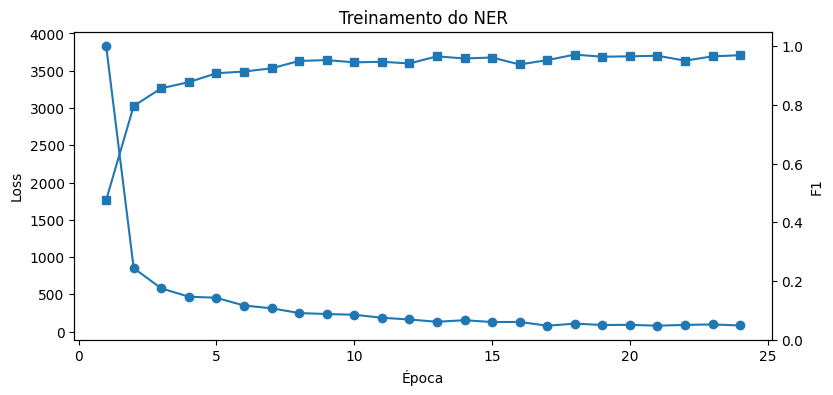

In [11]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(historico_df['epoca'], historico_df['loss'], marker='o', label='Loss de treino')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')

ax2 = ax1.twinx()
ax2.plot(historico_df['epoca'], historico_df['val_f1'], marker='s', label='F1 de validação')
ax2.set_ylabel('F1')
ax2.set_ylim(0, 1.05)

plt.title('Treinamento do NER')
plt.show()

## 8. Avaliação em validação e conjunto-desafio

A validação continua baseada em rótulos automáticos. O conjunto-desafio contém frases escritas separadamente, exemplos negativos e números, ajudando a revelar falsos positivos que não aparecem na validação comum.

In [12]:
def avaliar_exemplos_spacy(nlp, examples):
    scores = nlp.evaluate(examples)
    gerais = {
        'precision': float(scores.get('ents_p', 0.0)),
        'recall': float(scores.get('ents_r', 0.0)),
        'f1': float(scores.get('ents_f', 0.0)),
    }

    por_tipo = []
    for label, valores in scores.get('ents_per_type', {}).items():
        por_tipo.append({
            'categoria': label,
            'precision': float(valores.get('p', 0.0)),
            'recall': float(valores.get('r', 0.0)),
            'f1': float(valores.get('f', 0.0)),
        })

    return gerais, pd.DataFrame(por_tipo)


metricas_validacao, metricas_validacao_por_tipo = avaliar_exemplos_spacy(nlp_ner, val_examples)
print('Métricas na validação por documento:')
print(json.dumps(metricas_validacao, indent=2, ensure_ascii=False))
display(metricas_validacao_por_tipo.sort_values('f1'))

Métricas na validação por documento:
{
  "precision": 0.966542750929368,
  "recall": 0.9774436090225563,
  "f1": 0.9719626168224298
}


,categoria,precision,recall,f1
4,EQUIPAMENTO,1.000000,0.714286,0.833333
8,APLICACAO,0.800000,1.000000,0.888889
6,PRATICA_PROCESSO,0.857143,1.000000,0.923077
7,BENEFICIO,0.941176,0.941176,0.941176
5,INSUMO,0.900000,1.000000,0.947368
1,DESAFIO,1.000000,0.935484,0.966667
3,INDICADOR,1.000000,0.952381,0.975610
0,CADEIA_PRODUTIVA,0.956522,1.000000,0.977778
2,TECNOLOGIA,0.983740,1.000000,0.991803


In [13]:
CASOS_DESAFIO = [
    {
        'texto': 'Em 2025, o relatório número 17 foi aprovado sem alterações.',
        'entidades': []
    },
    {
        'texto': 'O drone coletou imagens multiespectrais para o monitoramento de lavouras de soja.',
        'entidades': [
            ('drone', 'EQUIPAMENTO'),
            ('imagens multiespectrais', 'TECNOLOGIA'),
            ('monitoramento de lavouras', 'APLICACAO'),
            ('soja', 'CADEIA_PRODUTIVA'),
        ]
    },
    {
        'texto': 'A inteligência artificial estimou a produtividade do milho sem classificar o ano 2024 como entidade.',
        'entidades': [
            ('inteligência artificial', 'TECNOLOGIA'),
            ('produtividade', 'INDICADOR'),
            ('milho', 'CADEIA_PRODUTIVA'),
        ]
    },
    {
        'texto': 'O plantio direto e a rotação de culturas contribuíram para a conservação do solo.',
        'entidades': [
            ('plantio direto', 'PRATICA_PROCESSO'),
            ('rotação de culturas', 'PRATICA_PROCESSO'),
            ('conservação do solo', 'BENEFICIO'),
        ]
    },
    {
        'texto': 'A equipe comprou 12 computadores, publicou um PDF e visitou Brasília.',
        'entidades': []
    },
    {
        'texto': 'Um sensor de umidade apoiou o controle de irrigação e a economia de água na produção de café.',
        'entidades': [
            ('sensor de umidade', 'EQUIPAMENTO'),
            ('controle de irrigação', 'APLICACAO'),
            ('economia de água', 'BENEFICIO'),
            ('café', 'CADEIA_PRODUTIVA'),
        ]
    },
    {
        'texto': 'O código 12345 e a versão 8.1 pertencem ao sistema administrativo.',
        'entidades': []
    },
]


def localizar_substring(texto, substring, label):
    inicio = texto.lower().find(substring.lower())
    if inicio < 0:
        raise ValueError(f'Substring não encontrada: {substring!r}')
    return inicio, inicio + len(substring), label


examples_desafio = []
for caso in CASOS_DESAFIO:
    entities = [
        localizar_substring(caso['texto'], substring, label)
        for substring, label in caso['entidades']
    ]
    doc = nlp_ner.make_doc(caso['texto'])
    examples_desafio.append(Example.from_dict(doc, {'entities': entities}))

metricas_desafio, metricas_desafio_por_tipo = avaliar_exemplos_spacy(nlp_ner, examples_desafio)
print('Métricas no conjunto-desafio:')
print(json.dumps(metricas_desafio, indent=2, ensure_ascii=False))
display(metricas_desafio_por_tipo.sort_values('f1'))

linhas_desafio = []
for caso in CASOS_DESAFIO:
    doc = nlp_ner(caso['texto'])
    linhas_desafio.append({
        'texto': caso['texto'],
        'esperado': '; '.join(f'{t} [{l}]' for t, l in caso['entidades']),
        'previsto': '; '.join(f'{e.text} [{e.label_}]' for e in doc.ents),
    })

display(pd.DataFrame(linhas_desafio))

Métricas no conjunto-desafio:
{
  "precision": 1.0,
  "recall": 0.5714285714285714,
  "f1": 0.7272727272727273
}


,categoria,precision,recall,f1
3,APLICACAO,0.0,0.0,0.000000
6,BENEFICIO,0.0,0.0,0.000000
5,PRATICA_PROCESSO,1.0,0.5,0.666667
0,EQUIPAMENTO,1.0,0.5,0.666667
2,CADEIA_PRODUTIVA,1.0,1.0,1.000000
1,TECNOLOGIA,1.0,1.0,1.000000
4,INDICADOR,1.0,1.0,1.000000


,texto,esperado,previsto
0,"Em 2025, o relatório número 17 foi aprovado se...",,
1,O drone coletou imagens multiespectrais para o...,drone [EQUIPAMENTO]; imagens multiespectrais [...,drone [EQUIPAMENTO]; imagens multiespectrais [...
2,A inteligência artificial estimou a produtivid...,inteligência artificial [TECNOLOGIA]; produtiv...,inteligência artificial [TECNOLOGIA]; produtiv...
3,O plantio direto e a rotação de culturas contr...,plantio direto [PRATICA_PROCESSO]; rotação de ...,plantio direto [PRATICA_PROCESSO]
4,"A equipe comprou 12 computadores, publicou um ...",,
5,Um sensor de umidade apoiou o controle de irri...,sensor de umidade [EQUIPAMENTO]; controle de i...,café [CADEIA_PRODUTIVA]
6,O código 12345 e a versão 8.1 pertencem ao sis...,,


## 9. Extração híbrida e filtros de qualidade

As correspondências exatas do dicionário têm prioridade. O NER pode acrescentar entidades não cobertas pelo léxico, mas previsões compostas apenas por números, símbolos ou fragmentos muito curtos são rejeitadas. Para `CADEIA_PRODUTIVA`, previsões fora do dicionário também são rejeitadas para impedir que números sejam classificados como culturas.

In [14]:
termos_por_label_normalizados = {
    label: {normalizar_texto(t) for t in termos}
    for label, termos in DICIONARIO_AGRO.items()
}


def sobrepoe(span_a, span_b):
    return span_a[0] < span_b[1] and span_a[1] > span_b[0]


def predicao_modelo_valida(texto_entidade, label):
    limpo = texto_entidade.strip()
    normalizado = normalizar_texto(limpo)

    if len(limpo) < 3:
        return False
    if not any(ch.isalpha() for ch in limpo):
        return False
    if re.fullmatch(r'[\d\W_]+', limpo):
        return False
    if label == 'CADEIA_PRODUTIVA' and normalizado not in termos_por_label_normalizados[label]:
        return False
    return True


def extrair_entidades_hibridas(texto):
    regras = [
        {'inicio': i, 'fim': f, 'categoria': label, 'origem': 'dicionario'}
        for i, f, label in extrair_spans_dicionario(texto)
    ]

    selecionadas = list(regras)
    doc_modelo = nlp_ner(texto)

    for ent in doc_modelo.ents:
        candidato = (ent.start_char, ent.end_char, ent.label_)
        if not predicao_modelo_valida(ent.text, ent.label_):
            continue
        if any(sobrepoe((ent.start_char, ent.end_char), (r['inicio'], r['fim'])) for r in selecionadas):
            continue
        selecionadas.append({
            'inicio': ent.start_char,
            'fim': ent.end_char,
            'categoria': ent.label_,
            'origem': 'modelo',
        })

    selecionadas = sorted(selecionadas, key=lambda x: (x['inicio'], -(x['fim'] - x['inicio'])))
    return selecionadas


registros_entidades = []
resumos_documentos = []

for _, row in df_textos.iterrows():
    entidades = extrair_entidades_hibridas(row['descricao'])
    resumo = []

    for ent in entidades:
        trecho = row['descricao'][ent['inicio']:ent['fim']]
        registros_entidades.append({
            'documento_id': int(row['documento_id']),
            'titulo': row['titulo'],
            'entidade': trecho,
            'categoria': ent['categoria'],
            'origem': ent['origem'],
            'inicio': ent['inicio'],
            'fim': ent['fim'],
        })
        resumo.append(f'{trecho} [{ent["categoria"]}]')

    resumos_documentos.append({
        'documento_id': int(row['documento_id']),
        'entidades_resumo': '; '.join(resumo),
        'quantidade_entidades': len(entidades),
    })


df_entidades = pd.DataFrame(
    registros_entidades,
    columns=['documento_id', 'titulo', 'entidade', 'categoria', 'origem', 'inicio', 'fim']
)
df_resumo_entidades = pd.DataFrame(resumos_documentos)
df_textos = df_textos.merge(df_resumo_entidades, on='documento_id', how='left')

print('Entidades extraídas:', len(df_entidades))
if not df_entidades.empty:
    display(pd.crosstab(df_entidades['categoria'], df_entidades['origem']))
    display(df_entidades.head(20))

Entidades extraídas: 1400


origem,dicionario,modelo
categoria,,
APLICACAO,34,11
BENEFICIO,87,30
CADEIA_PRODUTIVA,215,0
DESAFIO,130,5
EQUIPAMENTO,22,4
INDICADOR,108,9
INSUMO,49,12
PRATICA_PROCESSO,67,10
TECNOLOGIA,583,24


,documento_id,titulo,entidade,categoria,origem,inicio,fim
0,1,Desenvolver uma linha de farofas com castanhas...,bioeconomia,PRATICA_PROCESSO,dicionario,354,365
1,2,Desenvolvimento de cobertura líquida para sorvete,bioeconomia,PRATICA_PROCESSO,dicionario,473,484
2,4,Desenvolvimento de massa alimentícia enriqueci...,sociedade,BENEFICIO,modelo,296,305
3,4,Desenvolvimento de massa alimentícia enriqueci...,trigo,CADEIA_PRODUTIVA,dicionario,674,679
4,4,Desenvolvimento de massa alimentícia enriqueci...,trigo,CADEIA_PRODUTIVA,dicionario,696,701
5,4,Desenvolvimento de massa alimentícia enriqueci...,batata,CADEIA_PRODUTIVA,dicionario,797,803
6,4,Desenvolvimento de massa alimentícia enriqueci...,mandioca,CADEIA_PRODUTIVA,dicionario,815,823
7,4,Desenvolvimento de massa alimentícia enriqueci...,batata,CADEIA_PRODUTIVA,dicionario,840,846
8,4,Desenvolvimento de massa alimentícia enriqueci...,mandioca,CADEIA_PRODUTIVA,dicionario,848,856
9,4,Desenvolvimento de massa alimentícia enriqueci...,biomassa,INDICADOR,dicionario,874,882


## 10. Preparação de todo o dataset para embeddings

Todas as descrições válidas são utilizadas, incluindo registros duplicados. Não existe filtro temático nem amostragem. A coluna `duplicado_descricao` permite verificar posteriormente o impacto de repetições.

In [15]:
df_analise = df_textos[df_textos['texto_cluster'].str.len() > 0].copy().reset_index(drop=True)

# A limitação só seria aplicada se o usuário definisse explicitamente um valor inteiro.
if MAX_TEXTOS_EMBEDDINGS is not None and len(df_analise) > MAX_TEXTOS_EMBEDDINGS:
    df_analise = df_analise.sample(
        MAX_TEXTOS_EMBEDDINGS,
        random_state=RANDOM_STATE
    ).sort_values('documento_id').reset_index(drop=True)

print('Textos válidos no corpus:', len(df_textos))
print('Textos usados nos embeddings:', len(df_analise))
print('Uso integral do corpus válido:', len(df_analise) == len(df_textos))
print('Textos duplicados mantidos nos embeddings:', int(df_analise['duplicado_descricao'].sum()))
print('Tamanho mediano dos textos:', int(df_analise['texto_cluster'].str.len().median()), 'caracteres')

Textos válidos no corpus: 2721
Textos usados nos embeddings: 2716
Uso integral do corpus válido: False
Textos duplicados mantidos nos embeddings: 40
Tamanho mediano dos textos: 202 caracteres


## 11. Embeddings com BERTimbau

In [16]:
from transformers import AutoModel, AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
modelo_bert = AutoModel.from_pretrained(MODEL_NAME).to(device)
modelo_bert.eval()


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    soma = torch.sum(last_hidden_state * mask, dim=1)
    denominador = torch.clamp(mask.sum(dim=1), min=1e-9)
    return soma / denominador


def gerar_embeddings(textos, batch_size=BATCH_SIZE):
    vetores = []

    for inicio in range(0, len(textos), batch_size):
        lote = textos[inicio:inicio + batch_size]
        encoded = tokenizer(
            lote,
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors='pt'
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = modelo_bert(**encoded)
            pooled = mean_pooling(outputs.last_hidden_state, encoded['attention_mask'])
            pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)

        vetores.append(pooled.cpu().numpy())

    return np.vstack(vetores)


embeddings_originais = gerar_embeddings(df_analise['texto_cluster'].tolist())
print('Formato dos embeddings:', embeddings_originais.shape)

# Redução intermediária diminui ruído e torna o KMeans mais estável.
n_componentes_cluster = min(50, embeddings_originais.shape[0] - 1, embeddings_originais.shape[1])
pca_cluster = PCA(n_components=n_componentes_cluster, random_state=RANDOM_STATE)
embeddings_reduzidos = pca_cluster.fit_transform(embeddings_originais)
embeddings_cluster = normalize(embeddings_reduzidos)

print('Dimensões usadas no KMeans:', embeddings_cluster.shape[1])
print('Variância preservada pelo PCA intermediário:', f'{pca_cluster.explained_variance_ratio_.sum():.3f}')

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Formato dos embeddings: (2716, 768)
Dimensões usadas no KMeans: 50
Variância preservada pelo PCA intermediário: 0.711


## 12. Escolha do número de clusters no dataset completo

Cada valor de `k` é testado com várias sementes. Além do silhouette, são calculados Davies–Bouldin, Calinski–Harabasz e estabilidade por Adjusted Rand Index. Como o corpus contém todos os assuntos do DL-2024, os clusters representam temas gerais; a presença de inovação agrícola será quantificada em cada grupo.

k selecionado: 2


,k,silhouette,silhouette_std,davies_bouldin,calinski_harabasz,estabilidade_ari,menor_cluster_pct,score_composto
0,2,0.113409,0.000000,2.679562,369.179810,1.000000,0.452135,0.989653
1,3,0.105709,0.000016,2.633216,307.332214,0.996746,0.312150,0.878021
2,4,0.080533,0.000048,2.799091,246.051315,0.994907,0.226510,0.577569
3,5,0.069233,0.000109,3.081111,208.013824,0.960473,0.171723,0.363917
4,6,0.068919,0.000419,3.008475,182.372177,0.945412,0.110898,0.338738
5,7,0.071642,0.000237,2.948346,164.768555,0.797750,0.081370,0.265887
6,8,0.074530,0.000623,2.908138,152.084167,0.877084,0.068778,0.336328
7,9,0.068712,0.008542,2.847475,141.296783,0.724612,0.046465,0.192127
8,10,0.070513,0.004035,2.749988,132.897720,0.659479,0.027467,0.133274
9,11,0.072310,0.000298,2.708936,126.286926,0.859923,0.018041,0.238295


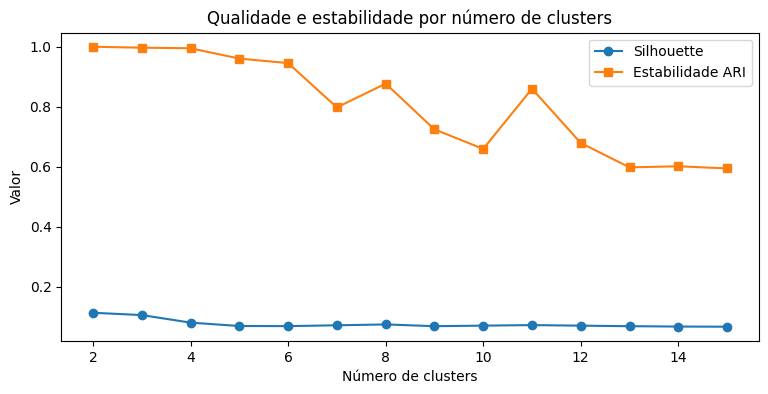

AVISO: silhouette abaixo de 0,20 indica sobreposição considerável entre os grupos.


In [17]:
def estabilidade_ari(lista_labels):
    if len(lista_labels) < 2:
        return 1.0
    valores = [
        adjusted_rand_score(a, b)
        for a, b in combinations(lista_labels, 2)
    ]
    return float(np.mean(valores))


n_amostras = len(df_analise)
max_k_ajustado = min(MAX_K, max(MIN_K, n_amostras // 12), n_amostras - 1)
ks = list(range(MIN_K, max_k_ajustado + 1))

resultados_k = []
for k in ks:
    labels_por_semente = []
    metricas_semente = []

    for seed in SEMENTES_CLUSTER:
        modelo_k = KMeans(n_clusters=k, random_state=seed, n_init=20)
        labels = modelo_k.fit_predict(embeddings_cluster)
        labels_por_semente.append(labels)

        contagens = np.bincount(labels, minlength=k)
        metricas_semente.append({
            'silhouette': silhouette_score(embeddings_cluster, labels),
            'davies_bouldin': davies_bouldin_score(embeddings_cluster, labels),
            'calinski_harabasz': calinski_harabasz_score(embeddings_cluster, labels),
            'menor_cluster_pct': contagens.min() / len(labels),
        })

    df_m = pd.DataFrame(metricas_semente)
    resultados_k.append({
        'k': k,
        'silhouette': df_m['silhouette'].mean(),
        'silhouette_std': df_m['silhouette'].std(),
        'davies_bouldin': df_m['davies_bouldin'].mean(),
        'calinski_harabasz': df_m['calinski_harabasz'].mean(),
        'estabilidade_ari': estabilidade_ari(labels_por_semente),
        'menor_cluster_pct': df_m['menor_cluster_pct'].mean(),
    })

metricas_cluster = pd.DataFrame(resultados_k)


def minmax(serie, inverter=False):
    serie = serie.astype(float)
    if np.isclose(serie.max(), serie.min()):
        resultado = pd.Series(np.ones(len(serie)), index=serie.index)
    else:
        resultado = (serie - serie.min()) / (serie.max() - serie.min())
    return 1 - resultado if inverter else resultado


metricas_cluster['score_composto'] = (
    0.40 * minmax(metricas_cluster['silhouette']) +
    0.25 * minmax(metricas_cluster['estabilidade_ari']) +
    0.15 * minmax(np.log1p(metricas_cluster['calinski_harabasz'])) +
    0.10 * minmax(metricas_cluster['davies_bouldin'], inverter=True) +
    0.10 * minmax(metricas_cluster['menor_cluster_pct'])
)

# Penaliza soluções com clusters menores que 3% do corpus.
metricas_cluster.loc[metricas_cluster['menor_cluster_pct'] < 0.03, 'score_composto'] *= 0.75

best_row = metricas_cluster.sort_values(
    ['score_composto', 'silhouette', 'estabilidade_ari'],
    ascending=False
).iloc[0]
best_k = int(best_row['k'])

print('k selecionado:', best_k)
display(metricas_cluster.sort_values('k'))

plt.figure(figsize=(9, 4))
plt.plot(metricas_cluster['k'], metricas_cluster['silhouette'], marker='o', label='Silhouette')
plt.plot(metricas_cluster['k'], metricas_cluster['estabilidade_ari'], marker='s', label='Estabilidade ARI')
plt.xlabel('Número de clusters')
plt.ylabel('Valor')
plt.title('Qualidade e estabilidade por número de clusters')
plt.legend()
plt.show()

if best_k == max_k_ajustado:
    print('AVISO: o melhor k está no limite testado. Considere aumentar MAX_K e revisar a interpretação.')
if float(best_row['silhouette']) < 0.20:
    print('AVISO: silhouette abaixo de 0,20 indica sobreposição considerável entre os grupos.')

## 13. KMeans final e distribuição dos grupos

In [18]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=50)
df_analise['cluster'] = kmeans.fit_predict(embeddings_cluster)

contagem_clusters = (
    df_analise
    .groupby('cluster')
    .agg(
        quantidade_textos=('documento_id', 'size'),
        textos_com_indicio_agro=('tem_indicio_agro', 'sum'),
        media_indicios_agro=('quantidade_indicios_agro', 'mean'),
        textos_duplicados=('duplicado_descricao', 'sum'),
    )
    .reset_index()
    .sort_values('cluster')
)
contagem_clusters['percentual'] = 100 * contagem_clusters['quantidade_textos'] / len(df_analise)
contagem_clusters['percentual_com_indicio_agro'] = (
    100 * contagem_clusters['textos_com_indicio_agro'] /
    contagem_clusters['quantidade_textos']
)
display(contagem_clusters)

,cluster,quantidade_textos,textos_com_indicio_agro,media_indicios_agro,textos_duplicados,percentual,percentual_com_indicio_agro
0,0,1488,129,0.121640,32,54.786451,8.669355
1,1,1228,219,0.295603,8,45.213549,17.833876


## 14. Termos distintivos por cluster

O TF-IDF é aplicado aos textos já limpos. As stopwords passam pela mesma normalização sem acentos usada pelo vetorizador.

In [19]:
STOPWORDS_PT_BASE = [
    'a','o','as','os','um','uma','uns','umas','de','do','da','dos','das','em','no','na','nos','nas',
    'por','pelo','pela','pelos','pelas','para','com','sem','sob','sobre','entre','até','apos','antes',
    'e','ou','mas','porem','contudo','que','se','quando','como','porque','pois','tambem','ainda','ja',
    'ser','estar','ter','haver','fazer','foi','foram','era','eram','sao','e','esta','estao','tem','têm',
    'pode','podem','deve','devem','mais','menos','muito','muita','muitos','muitas','ao','aos','partir',
    'projeto','projetos','desenvolvimento','desenvolver','desenvolvido','solucao','solucoes','sistema',
    'sistemas','processo','processos','produto','produtos','tecnologia','tecnologias','uso','utilizacao',
    'aplicacao','aplicacoes','metodo','metodos','modelo','modelos','analise','avaliacao','estudo',
    'pesquisa','dados','informacoes','empresa','empresas','area','areas','setor','setores','objetivo',
    'objetivos','resultado','resultados','forma','meio','parte','tipo','nivel','presente','proposta'
]
STOPWORDS_PT = sorted({normalizar_texto(x) for x in STOPWORDS_PT_BASE})

vectorizer = TfidfVectorizer(
    max_features=8000,
    stop_words=STOPWORDS_PT,
    ngram_range=(1, 3),
    min_df=2 if len(df_analise) >= 80 else 1,
    max_df=0.85,
    lowercase=True,
    strip_accents='unicode',
    sublinear_tf=True,
)

tfidf_matrix = vectorizer.fit_transform(df_analise['texto_cluster'])
termos = np.array(vectorizer.get_feature_names_out())

linhas_termos = []
for cluster_id in sorted(df_analise['cluster'].unique()):
    indices = np.where(df_analise['cluster'].values == cluster_id)[0]
    media = np.asarray(tfidf_matrix[indices].mean(axis=0)).ravel()
    top_idx = media.argsort()[::-1][:20]
    linhas_termos.append({
        'cluster': int(cluster_id),
        'quantidade_textos': len(indices),
        'termos_representativos': ', '.join(termos[top_idx]),
    })

cluster_terms_df = pd.DataFrame(linhas_termos)
display(cluster_terms_df)

,cluster,quantidade_textos,termos_representativos
0,0,1488,"software, producao, plataforma, controle, prot..."
1,1,1228,"producao, este, visa, sera, atraves, visando, ..."


## 15. Entidades mais frequentes e rótulos sugeridos

In [20]:
ids_analise = set(df_analise['documento_id'])
df_entidades_analise = df_entidades[df_entidades['documento_id'].isin(ids_analise)].copy()
df_entidades_analise = df_entidades_analise.merge(
    df_analise[['documento_id', 'cluster']],
    on='documento_id',
    how='left'
)

if not df_entidades_analise.empty:
    frequencia_entidades_cluster = (
        df_entidades_analise
        .assign(entidade_normalizada=lambda x: x['entidade'].map(normalizar_texto))
        .groupby(['cluster', 'categoria', 'entidade_normalizada'])
        .size()
        .reset_index(name='frequencia')
        .sort_values(['cluster', 'frequencia'], ascending=[True, False])
    )
    top_entidades_clusters = frequencia_entidades_cluster.groupby('cluster', group_keys=False).head(20)
    display(top_entidades_clusters)
else:
    top_entidades_clusters = pd.DataFrame()
    print('Nenhuma entidade foi reconhecida nos textos usados para clustering.')

CATEGORIAS_PRIORITARIAS_ROTULO = ['TECNOLOGIA', 'APLICACAO', 'PRATICA_PROCESSO', 'CADEIA_PRODUTIVA', 'INSUMO']

rotulos = []
for cluster_id in sorted(df_analise['cluster'].unique()):
    itens = []
    if not top_entidades_clusters.empty:
        subset = top_entidades_clusters[
            (top_entidades_clusters['cluster'] == cluster_id) &
            (top_entidades_clusters['categoria'].isin(CATEGORIAS_PRIORITARIAS_ROTULO))
        ]
        itens = subset['entidade_normalizada'].drop_duplicates().head(3).tolist()

    if len(itens) < 2:
        termos_cluster = cluster_terms_df.loc[
            cluster_terms_df['cluster'] == cluster_id,
            'termos_representativos'
        ].iloc[0].split(', ')
        itens.extend([t for t in termos_cluster if t not in itens][:3-len(itens)])

    rotulos.append({
        'cluster': int(cluster_id),
        'rotulo_sugerido': ' | '.join(itens) if itens else f'Cluster {cluster_id}'
    })

rotulos_clusters_df = pd.DataFrame(rotulos)
display(rotulos_clusters_df)

,cluster,categoria,entidade_normalizada,frequencia
102,0,TECNOLOGIA,inteligencia artificial,50
106,0,TECNOLOGIA,iot,29
117,0,TECNOLOGIA,visao computacional,26
99,0,TECNOLOGIA,ia,16
31,0,CADEIA_PRODUTIVA,soja,15
91,0,TECNOLOGIA,computacao em nuvem,13
25,0,CADEIA_PRODUTIVA,cana-de-acucar,12
39,0,DESAFIO,pragas,12
47,0,INDICADOR,biomassa,12
85,0,TECNOLOGIA,aprendizado de maquina,12


,cluster,rotulo_sugerido
0,0,inteligencia artificial | iot | visao computac...
1,1,inteligencia artificial | iot | ia


## 16. Textos mais próximos dos centroides

In [21]:
distancias = kmeans.transform(embeddings_cluster)
representantes = []

for cluster_id in sorted(df_analise['cluster'].unique()):
    indices = np.where(df_analise['cluster'].values == cluster_id)[0]
    ordem = np.argsort(distancias[indices, cluster_id])[:5]

    for posicao, idx_local in enumerate(ordem, start=1):
        idx_global = indices[idx_local]
        row = df_analise.iloc[idx_global]
        representantes.append({
            'cluster': int(cluster_id),
            'posicao': posicao,
            'titulo': row['titulo'],
            'texto': row['texto_cluster'],
            'distancia_centroide': float(distancias[idx_global, cluster_id]),
        })

representantes_df = pd.DataFrame(representantes).merge(rotulos_clusters_df, on='cluster', how='left')
display(representantes_df)

,cluster,posicao,titulo,texto,distancia_centroide,rotulo_sugerido
0,0,1,Plataforma de gerenciamento de conectividade v...,Desenvolvimento de plataforma de gerenciamento...,0.834761,inteligencia artificial | iot | visao computac...
1,0,2,Filtro Ativo para Redes Elétricas,Desenvolvimento (software e hardware) de filtr...,0.836435,inteligencia artificial | iot | visao computac...
2,0,3,Solução para processamento de sinais de pesagem,Desenvolvimento de hardware e firmware para pr...,0.837282,inteligencia artificial | iot | visao computac...
3,0,4,DATACENTER SIMULATOR EMBRAPII,Software de simulação de datacenter,0.840521,inteligencia artificial | iot | visao computac...
4,0,5,Execução de testes através de Dispositivos Móv...,Solução de software para testes de terminais d...,0.842227,inteligencia artificial | iot | visao computac...
5,1,1,Avaliação numérica e experimental do desempenh...,uma avaliação numérica e experimental do desem...,0.680386,inteligencia artificial | iot | ia
6,1,2,Aplicação de novas tecnologias de manufatura a...,"Atualmente, o setor de petróleo e gás (O&G) en...",0.683860,inteligencia artificial | iot | ia
7,1,3,Projeto Resíduo Madeireiro,"Dentre as atividades florestais, a colheita fl...",0.685091,inteligencia artificial | iot | ia
8,1,4,SYSENERGYPLUS - uma solução para gestão e efic...,A energia é um insumo crítico na operação das ...,0.688467,inteligencia artificial | iot | ia
9,1,5,Monitoramento da vida útil do ciclo de produto...,Desenvolver uma estrutura que fomente futuras ...,0.689260,inteligencia artificial | iot | ia


## 17. Visualizações exploratórias

PCA e t-SNE ajudam a inspecionar a distribuição, mas não comprovam sozinhos que os grupos representam temas reais.

Variância explicada pelas duas componentes: 0.199


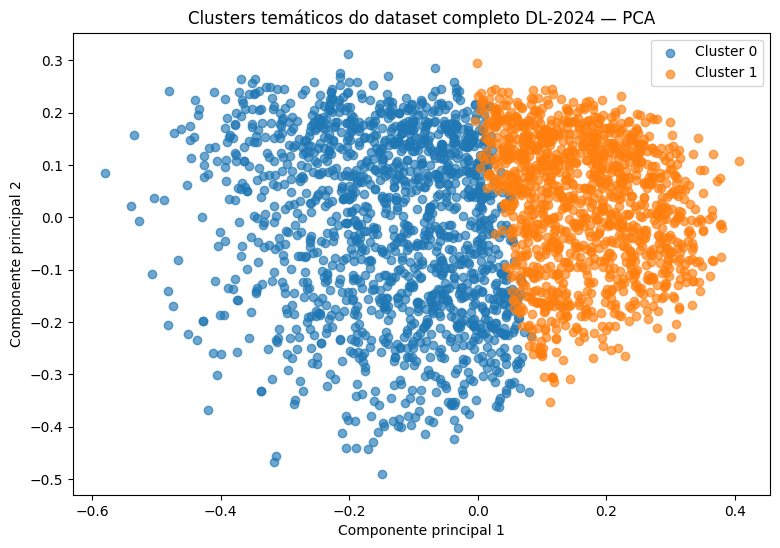

In [22]:
pca_visual = PCA(n_components=2, random_state=RANDOM_STATE)
pontos_pca = pca_visual.fit_transform(embeddings_originais)

pca_df = pd.DataFrame({
    'x': pontos_pca[:, 0],
    'y': pontos_pca[:, 1],
    'cluster': df_analise['cluster'].astype(str),
})

print('Variância explicada pelas duas componentes:', f'{pca_visual.explained_variance_ratio_.sum():.3f}')

plt.figure(figsize=(9, 6))
for cluster_id in sorted(pca_df['cluster'].unique()):
    subset = pca_df[pca_df['cluster'] == cluster_id]
    plt.scatter(subset['x'], subset['y'], label=f'Cluster {cluster_id}', alpha=0.65)
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Clusters temáticos do dataset completo DL-2024 — PCA')
plt.legend()
plt.show()

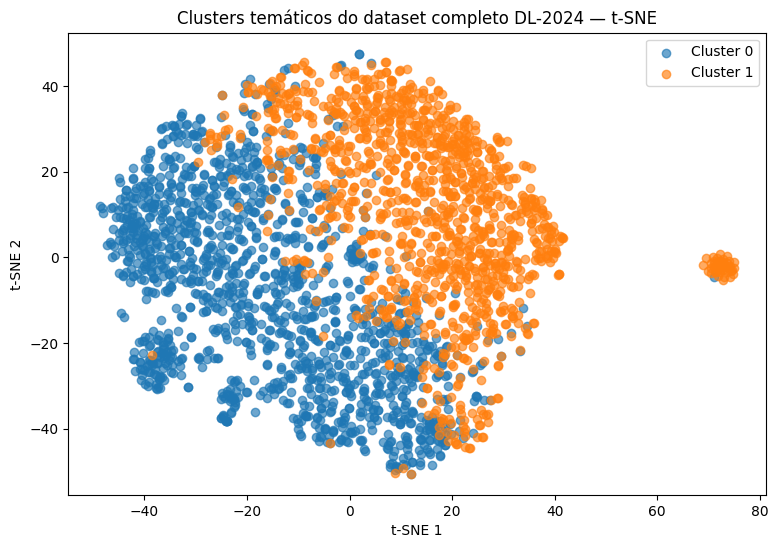

In [23]:
if len(df_analise) >= 15:
    perplexity = min(35, max(5, (len(df_analise) - 1) // 4))
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate='auto',
        init='pca',
        random_state=RANDOM_STATE,
    )
    pontos_tsne = tsne.fit_transform(embeddings_cluster)

    tsne_df = pd.DataFrame({
        'x': pontos_tsne[:, 0],
        'y': pontos_tsne[:, 1],
        'cluster': df_analise['cluster'].astype(str),
    })

    plt.figure(figsize=(9, 6))
    for cluster_id in sorted(tsne_df['cluster'].unique()):
        subset = tsne_df[tsne_df['cluster'] == cluster_id]
        plt.scatter(subset['x'], subset['y'], label=f'Cluster {cluster_id}', alpha=0.65)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title('Clusters temáticos do dataset completo DL-2024 — t-SNE')
    plt.legend()
    plt.show()
else:
    print('t-SNE ignorado: menos de 15 textos.')

## 18. Resumo consolidado dos clusters

In [24]:
resumo_clusters = (
    contagem_clusters
    .merge(cluster_terms_df.drop(columns=['quantidade_textos']), on='cluster', how='left')
    .merge(rotulos_clusters_df, on='cluster', how='left')
)

if not top_entidades_clusters.empty:
    entidades_resumo = (
        top_entidades_clusters
        .assign(item=lambda x: x['entidade_normalizada'] + ' [' + x['categoria'] + ']')
        .groupby('cluster')['item']
        .apply(lambda s: '; '.join(s.head(12)))
        .reset_index(name='entidades_representativas')
    )
    resumo_clusters = resumo_clusters.merge(entidades_resumo, on='cluster', how='left')
else:
    resumo_clusters['entidades_representativas'] = ''

resumo_clusters['silhouette'] = float(best_row['silhouette'])
resumo_clusters['estabilidade_ari'] = float(best_row['estabilidade_ari'])
resumo_clusters['davies_bouldin'] = float(best_row['davies_bouldin'])
resumo_clusters['total_corpus_analisado'] = len(df_analise)
resumo_clusters['fonte_corpus'] = nome_fonte

display(resumo_clusters)

,cluster,quantidade_textos,textos_com_indicio_agro,media_indicios_agro,textos_duplicados,percentual,percentual_com_indicio_agro,termos_representativos,rotulo_sugerido,entidades_representativas,silhouette,estabilidade_ari,davies_bouldin,total_corpus_analisado,fonte_corpus
0,0,1488,129,0.121640,32,54.786451,8.669355,"software, producao, plataforma, controle, prot...",inteligencia artificial | iot | visao computac...,inteligencia artificial [TECNOLOGIA]; iot [TEC...,0.113409,1.0,2.679562,2716,DL-2024
1,1,1228,219,0.295603,8,45.213549,17.833876,"producao, este, visa, sera, atraves, visando, ...",inteligencia artificial | iot | ia,inteligencia artificial [TECNOLOGIA]; produtiv...,0.113409,1.0,2.679562,2716,DL-2024


## 19. Exportação dos resultados do dataset completo

In [25]:
OUTPUT_DIR = Path('resultados_dl2024_completo_agro_v3')
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_DIR = OUTPUT_DIR / 'modelo_ner_agro'
if MODEL_DIR.exists():
    shutil.rmtree(MODEL_DIR)
nlp_ner.to_disk(MODEL_DIR)

arquivos = {
    'corpus_completo': OUTPUT_DIR / 'dl2024_corpus_completo.csv',
    'textos_clusters': OUTPUT_DIR / 'dl2024_textos_clusters.csv',
    'entidades': OUTPUT_DIR / 'dl2024_entidades_agro_hibridas.csv',
    'resumo_clusters': OUTPUT_DIR / 'dl2024_resumo_clusters.csv',
    'representantes': OUTPUT_DIR / 'dl2024_textos_representativos.csv',
    'dicionario': OUTPUT_DIR / 'dicionario_agro.csv',
    'metricas_k': OUTPUT_DIR / 'metricas_cluster_por_k.csv',
    'metricas_ner_tipo': OUTPUT_DIR / 'metricas_ner_validacao_por_tipo.csv',
    'historico_ner': OUTPUT_DIR / 'historico_treinamento_ner.csv',
}

df_textos.to_csv(arquivos['corpus_completo'], index=False, encoding='utf-8-sig')
df_analise.to_csv(arquivos['textos_clusters'], index=False, encoding='utf-8-sig')
df_entidades.to_csv(arquivos['entidades'], index=False, encoding='utf-8-sig')
resumo_clusters.to_csv(arquivos['resumo_clusters'], index=False, encoding='utf-8-sig')
representantes_df.to_csv(arquivos['representantes'], index=False, encoding='utf-8-sig')
df_dicionario.to_csv(arquivos['dicionario'], index=False, encoding='utf-8-sig')
metricas_cluster.to_csv(arquivos['metricas_k'], index=False, encoding='utf-8-sig')
metricas_validacao_por_tipo.to_csv(arquivos['metricas_ner_tipo'], index=False, encoding='utf-8-sig')
historico_df.to_csv(arquivos['historico_ner'], index=False, encoding='utf-8-sig')

with open(OUTPUT_DIR / 'metricas_ner.json', 'w', encoding='utf-8') as f:
    json.dump({
        'validacao_weak_supervision': metricas_validacao,
        'conjunto_desafio': metricas_desafio,
        'fonte_corpus': nome_fonte,
        'arquivo_fonte': caminho_fonte,
        'registros_brutos': int(len(df_bruto)),
        'registros_validos_utilizados': int(len(df_textos)),
        'textos_embeddings': int(len(df_analise)),
        'dataset_completo_sem_filtro_tematico': True,
    }, f, ensure_ascii=False, indent=2)

zip_path = shutil.make_archive('entrega_dl2024_completo_agro_v3', 'zip', root_dir=OUTPUT_DIR)

print('Arquivos gerados:')
for nome, caminho in arquivos.items():
    print(f'- {nome}: {caminho}')
print('- modelo NER:', MODEL_DIR)
print('- pacote ZIP:', zip_path)

Arquivos gerados:
- corpus_completo: resultados_dl2024_completo_agro_v3/dl2024_corpus_completo.csv
- textos_clusters: resultados_dl2024_completo_agro_v3/dl2024_textos_clusters.csv
- entidades: resultados_dl2024_completo_agro_v3/dl2024_entidades_agro_hibridas.csv
- resumo_clusters: resultados_dl2024_completo_agro_v3/dl2024_resumo_clusters.csv
- representantes: resultados_dl2024_completo_agro_v3/dl2024_textos_representativos.csv
- dicionario: resultados_dl2024_completo_agro_v3/dicionario_agro.csv
- metricas_k: resultados_dl2024_completo_agro_v3/metricas_cluster_por_k.csv
- metricas_ner_tipo: resultados_dl2024_completo_agro_v3/metricas_ner_validacao_por_tipo.csv
- historico_ner: resultados_dl2024_completo_agro_v3/historico_treinamento_ner.csv
- modelo NER: resultados_dl2024_completo_agro_v3/modelo_ner_agro
- pacote ZIP: /content/entrega_dl2024_completo_agro_v3.zip





> O projeto aplicou um fluxo de Processamento de Linguagem Natural sobre todas as descrições válidas do dataset DL-2024. Nenhum registro foi excluído por assunto e nenhuma amostragem foi aplicada na geração dos embeddings. O dicionário especializado do agronegócio foi empregado como mecanismo de *weak supervision* para identificar tecnologias, equipamentos, práticas, insumos, cadeias produtivas, aplicações, benefícios, desafios e indicadores agrícolas ao longo do corpus completo. As descrições duplicadas foram mantidas para preservar integralmente o dataset, mas foram agrupadas na divisão entre treino e validação para evitar vazamento. O NER foi avaliado em validação automática e em um conjunto-desafio separado. O BERTimbau gerou representações semânticas de todos os textos válidos, posteriormente normalizadas e utilizadas no KMeans. Como a clusterização considerou o dataset inteiro, os grupos representam temas gerais, sendo a presença de conteúdo agrícola quantificada dentro de cada cluster. Os resultados devem ser interpretados como exploratórios, pois uma validação definitiva exige anotações humanas.